In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('../data/city_day.csv')
print(f"Raw data shape: {df.shape}")
df.head()

Raw data shape: (29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [2]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df)

            Missing Count  Missing %
Xylene              18109      61.32
PM10                11140      37.72
NH3                 10328      34.97
Toluene              8041      27.23
Benzene              5623      19.04
AQI                  4681      15.85
AQI_Bucket           4681      15.85
PM2.5                4598      15.57
NOx                  4185      14.17
O3                   4022      13.62
SO2                  3854      13.05
NO2                  3585      12.14
NO                   3582      12.13
CO                   2059       6.97
City                    0       0.00
Date                    0       0.00


In [3]:
# Convert Date to datetime 
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful time features right now
df['Year']        = df['Date'].dt.year
df['Month']       = df['Date'].dt.month
df['Day']         = df['Date'].dt.day
df['DayOfWeek']   = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Quarter']     = df['Date'].dt.quarter

print("Date range:", df['Date'].min(), "→", df['Date'].max())
print("Time features added ✓")

Date range: 2015-01-01 00:00:00 → 2020-07-01 00:00:00
Time features added ✓


In [4]:
# Benzene, Toluene, Xylene have very high missing % and low AQI impact
# AQI_Bucket is just a text label — we have AQI value already
cols_to_drop = ['Benzene', 'Toluene', 'Xylene', 'AQI_Bucket']
df = df.drop(columns=cols_to_drop)

print(f"Columns after drop: {df.shape[1]}")
print(f"Remaining columns: {list(df.columns)}")

Columns after drop: 17
Remaining columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI', 'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter']


In [5]:
# For time-series data, forward fill is the correct strategy


# Sort by City and Date first — CRITICAL before filling
df = df.sort_values(['City', 'Date']).reset_index(drop=True)

# Columns to fill
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3']

# Forward fill within each city's time series
df[pollutant_cols] = df.groupby('City')[pollutant_cols].ffill()

# Backward fill to catch any remaining NaNs at the start
df[pollutant_cols] = df.groupby('City')[pollutant_cols].bfill()

print("After filling pollutants:")
print(df[pollutant_cols].isnull().sum())

After filling pollutants:
PM2.5       0
PM10     2009
NO          0
NO2         0
NOx      1169
NH3      2009
CO          0
SO2         0
O3        162
dtype: int64


In [6]:
# we drop rows where AQI is missing

rows_before = len(df)
df = df.dropna(subset=['AQI'])
rows_after = len(df)

print(f"Rows removed (missing AQI): {rows_before - rows_after}")
print(f"Rows remaining: {rows_after:,}")
print(f"Missing AQI now: {df['AQI'].isnull().sum()}")

Rows removed (missing AQI): 4681
Rows remaining: 24,850
Missing AQI now: 0


In [7]:
# Use IQR method to cap extreme outliers — don't delete, just cap
# This preserves data while removing unrealistic spikes

def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    return series.clip(lower=lower, upper=upper)

for col in pollutant_cols:
    before_max = df[col].max()
    df[col] = cap_outliers(df[col])
    after_max = df[col].max()
    if before_max != after_max:
        print(f"{col}: max {before_max:.1f} → {after_max:.1f} (capped)")

print("\nOutlier capping complete ✓")

PM2.5: max 914.9 → 242.2 (capped)
PM10: max 917.1 → 468.2 (capped)
NO: max 390.7 → 63.3 (capped)
NO2: max 362.2 → 116.6 (capped)
NOx: max 378.2 → 120.5 (capped)
NH3: max 352.9 → 132.0 (capped)
CO: max 175.8 → 4.1 (capped)
SO2: max 186.1 → 44.2 (capped)
O3: max 257.7 → 126.7 (capped)

Outlier capping complete ✓


In [8]:
print("=" * 45)
print("CLEAN DATASET SUMMARY")
print("=" * 45)
print(f"Shape          : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Date range     : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Cities         : {df['City'].nunique()}")
print(f"AQI range      : {df['AQI'].min():.1f} → {df['AQI'].max():.1f}")
print(f"AQI mean       : {df['AQI'].mean():.1f}")

CLEAN DATASET SUMMARY
Shape          : (24850, 17)
Missing values : 4151
Date range     : 2015-01-01 → 2020-07-01
Cities         : 26
AQI range      : 13.0 → 2049.0
AQI mean       : 166.5


In [9]:
df.to_csv('../data/clean_aqi.csv', index=False)
print("clean_aqi.csv saved to data/ ✓")
print("This is the file all future notebooks will use.")

clean_aqi.csv saved to data/ ✓
This is the file all future notebooks will use.


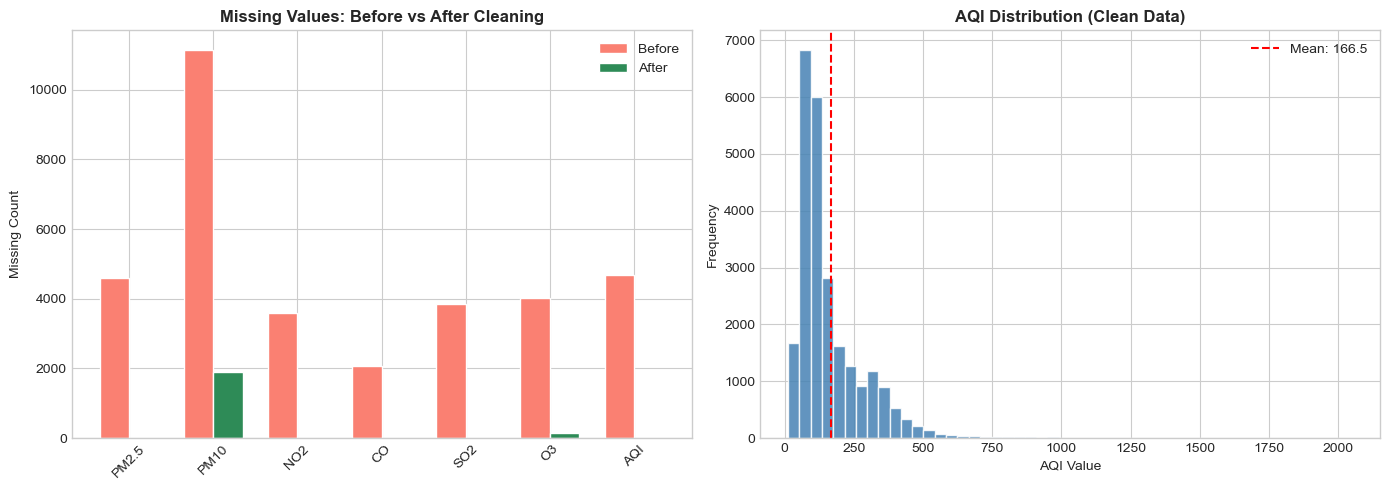

Plot saved ✓


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before/After missing values comparison
original = pd.read_csv('../data/city_day.csv')
cols_check = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI']

missing_before = original[cols_check].isnull().sum()
missing_after  = df[cols_check].isnull().sum()

x = range(len(cols_check))
width = 0.35
axes[0].bar([i - width/2 for i in x], missing_before, width, 
            label='Before', color='salmon', edgecolor='white')
axes[0].bar([i + width/2 for i in x], missing_after, width,  
            label='After',  color='seagreen', edgecolor='white')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(cols_check, rotation=45)
axes[0].set_title('Missing Values: Before vs After Cleaning', fontweight='bold')
axes[0].set_ylabel('Missing Count')
axes[0].legend()

# AQI distribution after cleaning
axes[1].hist(df['AQI'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('AQI Distribution (Clean Data)', fontweight='bold')
axes[1].set_xlabel('AQI Value')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['AQI'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['AQI'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('../visualizations/02_cleaning_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

In [11]:
# Investigate the impossible AQI values
print(f"Rows with AQI > 500: {(df['AQI'] > 500).sum()}")
print(f"Rows with AQI > 1000: {(df['AQI'] > 1000).sum()}")
print()
print("Cities with AQI > 500:")
print(df[df['AQI'] > 500].groupby('City')['AQI'].agg(['count', 'max', 'mean']).round(1))
print()
print("Sample of extreme AQI rows:")
print(df[df['AQI'] > 500][['City', 'Date', 'PM2.5', 'PM10', 'AQI']].head(10))

Rows with AQI > 500: 543
Rows with AQI > 1000: 93

Cities with AQI > 500:
            count     max   mean
City                            
Ahmedabad     412  2049.0  811.1
Amritsar        4   869.0  708.8
Delhi          48   716.0  559.6
Gurugram       22   891.0  597.0
Guwahati        2   956.0  897.0
Hyderabad       4   737.0  602.5
Jorapokhar      7   604.0  559.4
Lucknow        15   707.0  565.9
Patna          25   619.0  540.7
Talcher         4   570.0  530.0

Sample of extreme AQI rows:
         City       Date   PM2.5    PM10     AQI
30  Ahmedabad 2015-01-31   94.52  141.54   514.0
31  Ahmedabad 2015-02-01  135.99  141.54   782.0
32  Ahmedabad 2015-02-02  178.33  141.54   914.0
33  Ahmedabad 2015-02-03  139.70  141.54   660.0
43  Ahmedabad 2015-02-13  103.36  141.54   510.0
44  Ahmedabad 2015-02-14  177.33  141.54   761.0
46  Ahmedabad 2015-02-16   99.70  141.54   536.0
48  Ahmedabad 2015-02-18  100.79  141.54   592.0
50  Ahmedabad 2015-02-20  140.29  141.54   588.0
51  Ahmedab

In [12]:
# India's official AQI scale is 0–500
# Values above 500 are data recording errors — we cap them, not delete
# Capping is better than deleting because it preserves the row's other features

aqi_before = df['AQI'].max()
df['AQI'] = df['AQI'].clip(upper=500)
aqi_after = df['AQI'].max()

print(f"AQI max before: {aqi_before:.1f}")
print(f"AQI max after : {aqi_after:.1f}")
print(f"Rows affected : {(df['AQI'] == 500).sum()}")

AQI max before: 2049.0
AQI max after : 500.0
Rows affected : 545


In [13]:
# After dropping AQI-null rows, some pollutant nulls remain
# because those rows had AQI but their city had no data at start/end
# We fill remaining nulls with city-wise median (safer than mean for skewed data)

pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3']

for col in pollutant_cols:
    # Fill remaining nulls with city-wise median
    df[col] = df.groupby('City')[col].transform(
        lambda x: x.fillna(x.median())
    )

print("Remaining missing values per column:")
print(df[pollutant_cols].isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Remaining missing values per column:
PM2.5       0
PM10     1893
NO          0
NO2         0
NOx       771
NH3      1334
CO          0
SO2         0
O3        153
dtype: int64

Total missing values: 4151


In [14]:
# AQI below 10 is also unrealistic for Indian cities
# Even the cleanest city (Aizawl) averages around 30+

print(f"Rows with AQI < 10: {(df['AQI'] < 10).sum()}")
df['AQI'] = df['AQI'].clip(lower=10)
print(f"AQI range now: {df['AQI'].min():.1f} → {df['AQI'].max():.1f}")

Rows with AQI < 10: 0
AQI range now: 13.0 → 500.0


In [15]:
print("=" * 45)
print("FINAL CLEAN DATASET SUMMARY")
print("=" * 45)
print(f"Shape          : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Date range     : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Cities         : {df['City'].nunique()}")
print(f"AQI range      : {df['AQI'].min():.1f} → {df['AQI'].max():.1f}  ✓ (valid)")
print(f"AQI mean       : {df['AQI'].mean():.1f}")
print()

# AQI category breakdown
def categorize_aqi(aqi):
    if aqi <= 50:    return '0-50 Good'
    elif aqi <= 100: return '51-100 Satisfactory'
    elif aqi <= 200: return '101-200 Moderate'
    elif aqi <= 300: return '201-300 Poor'
    elif aqi <= 400: return '301-400 Very Poor'
    else:            return '401-500 Severe'

df['AQI_Category'] = df['AQI'].apply(categorize_aqi)
print("AQI Category Distribution:")
print(df['AQI_Category'].value_counts().sort_index())

FINAL CLEAN DATASET SUMMARY
Shape          : (24850, 17)
Missing values : 4151
Date range     : 2015-01-01 → 2020-07-01
Cities         : 26
AQI range      : 13.0 → 500.0  ✓ (valid)
AQI mean       : 160.9

AQI Category Distribution:
AQI_Category
0-50 Good              1341
101-200 Moderate       8829
201-300 Poor           2781
301-400 Very Poor      2337
401-500 Severe         1338
51-100 Satisfactory    8224
Name: count, dtype: int64


In [16]:
# Drop AQI_Category before saving (it's derived, not a feature)
df = df.drop(columns=['AQI_Category'])

df.to_csv('../data/clean_aqi.csv', index=False)
print("✅ clean_aqi.csv saved successfully!")
print(f"   Final shape: {df.shape}")
print(f"   AQI range  : {df['AQI'].min():.0f} → {df['AQI'].max():.0f}")
print(f"   Zero nulls : {df.isnull().sum().sum() == 0}")

✅ clean_aqi.csv saved successfully!
   Final shape: (24850, 17)
   AQI range  : 13 → 500
   Zero nulls : False


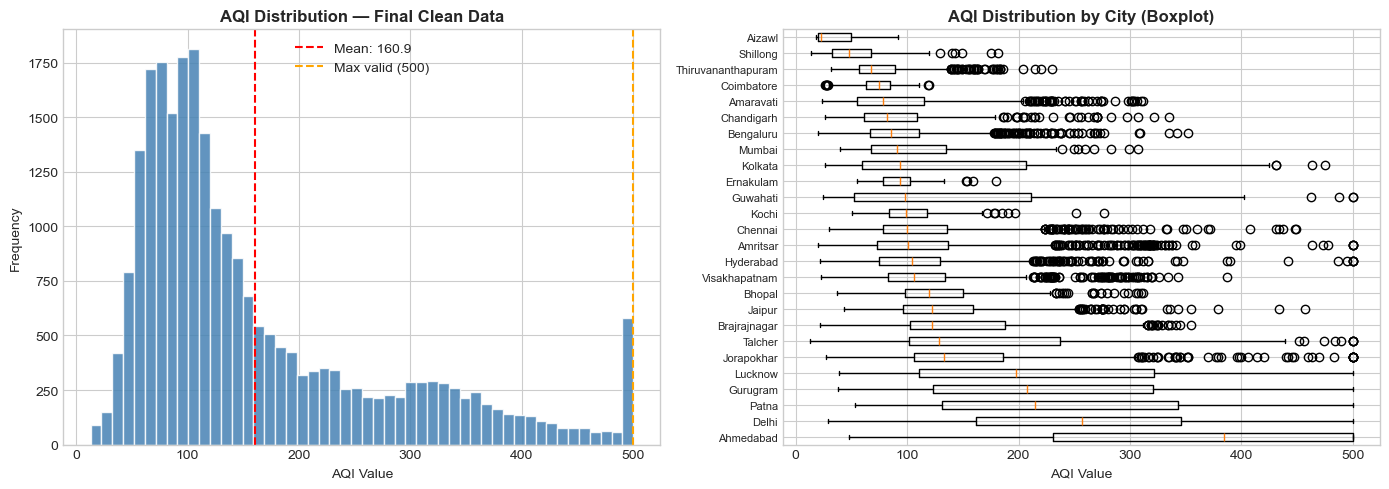

Plot saved ✓


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clean AQI distribution
axes[0].hist(df['AQI'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('AQI Distribution — Final Clean Data', fontweight='bold')
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['AQI'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['AQI'].mean():.1f}")
axes[0].axvline(500, color='orange', linestyle='--', label='Max valid (500)')
axes[0].legend()

# City-wise AQI boxplot
city_order = df.groupby('City')['AQI'].median().sort_values(ascending=False).index
city_data  = [df[df['City'] == c]['AQI'].values for c in city_order]
axes[1].boxplot(city_data, labels=city_order, vert=False)
axes[1].set_title('AQI Distribution by City (Boxplot)', fontweight='bold')
axes[1].set_xlabel('AQI Value')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../visualizations/03_final_clean_data.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")